In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [17]:


df = pd.read_csv('Les_reponses.csv')

print(f"Dataset shape: {df.shape}")
display(df.head(5))

df.info()

print(df.columns)

Dataset shape: (145, 14)


,Horodateur,Votre genre,Votre Age,Niveau académique,votre spécialité,Avez-vous déjà effectué un stage,Êtes-vous actuellement en recherche d’emploi ?,Quelles sont les principales difficultés que vous rencontrez pour trouver un emploi ?,Dans quelle ville recherchez vous principalement un emploi ?,"Selon vous, quelle compétence est la plus importante pour être recruté(e) ?",Pensez vous que votre formation vous a bien prépare au Marche de travail ?,Avez-vous déjà refusé une offre d’emploi ?,si oui pourquoi ?,"Selon vous, quel est le salaire minimum que vous seriez prêt à accepter pour un tel emploi ? (en dh)"
0,2025/05/01 11:14:56 PM UTC+1,Femme,[20;25[,Master,Informatique et science des données,Oui,Non,Manque d’expérience,Rabat,Techniques,Moyennement,Oui,Conditions de travail difficiles,6500
1,2025/05/01 11:15:59 PM UTC+1,Femme,[20;25[,Master,Mathématique,Oui,Non,Peu d’offres;Salaire faible,Rabat,Techniques,Moyennement,Non,NaN,7000dh
2,2025/05/01 11:16:17 PM UTC+1,Homme,[20;25[,Master,Mathématique,Non,Non,Compétences non adaptées,Ben hmed,Techniques,Moyennement,Non,NaN,10000
3,2025/05/01 11:27:25 PM UTC+1,Homme,[20;25[,Master,Informatique et science des données,Oui,Non,Manque d’expérience,Rabat,"Soft skills ( travail d'équipe, leadership, co...",Oui,Oui,Conditions salariales insuffisantes,8000dh
4,2025/05/01 11:36:15 PM UTC+1,Femme,[20;25[,licence,Mathématique,Oui,Non,Peu d’offres,Salé,"Soft skills ( travail d'équipe, leadership, co...",Oui,Non,NaN,6000dh


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 14 columns):
 #   Column                                                                                                Non-Null Count  Dtype 
---  ------                                                                                                --------------  ----- 
 0   Horodateur                                                                                            145 non-null    object
 1   Votre genre                                                                                           145 non-null    object
 2   Votre Age                                                                                             145 non-null    object
 3   Niveau académique                                                                                     145 non-null    object
 4   votre spécialité                                                                                      145 non-

In [18]:
#netoyage des colonne

df = df.drop(columns=['Horodateur'])
df = df.rename(columns={'Votre genre': 'Genre',
               'Votre Age ': 'Age',
               'Niveau académique': 'Niveau academique',
               'votre spécialité ': 'Specialite',
               ' Avez-vous déjà effectué un stage   ': 'Stage',
               'Êtes-vous actuellement en recherche d’emploi ?  ': 'recherche d-emploi',
               'Quelles sont les principales difficultés que vous rencontrez pour trouver un emploi ?  ': 'Freins',
               'Dans quelle ville recherchez vous principalement un emploi ?  ': 'Ville',
               'Selon vous, quelle compétence est la plus importante pour être recruté(e) ?': 'Competence',
               'Pensez vous que votre formation vous a bien prépare au Marche de travail ?': 'Formation',
               'Avez-vous déjà refusé une offre d’emploi ?': 'Refus d-emploi',
               'si oui pourquoi ?': 'raison de refus',
               'Selon vous, quel est le salaire minimum que vous seriez prêt à accepter pour un tel emploi ? (en dh)': 'Salaire min'
                       })

In [19]:
#genre

df['Genre'] = df['Genre'].replace(['Femme'],'0')
df['Genre'] = df['Genre'].replace(['Homme'],'1')
df['Genre'] = df['Genre'].astype(int)

In [20]:
#salaire min

df['Salaire min'] = df['Salaire min'].str.replace(r'\D', '', regex=True)
df['Salaire min'] = df['Salaire min'].astype(int)

mediane = df['Salaire min'].median()
df['Salaire min'] = df['Salaire min'].apply(lambda x: mediane if (x > 80000 or x < 2000) else x)


In [21]:
#ville

import unicodedata
def nettoyer_texte(texte):
    texte = texte.lower()  # mettre en minuscule
    texte = unicodedata.normalize('NFD', texte).encode('ascii', 'ignore').decode('utf-8')
    return texte

df['Ville'] = df['Ville'].apply(nettoyer_texte)
df['Ville'] = df['Ville'].str.replace(' ', '', regex=False)

counts = df['Ville'].value_counts()
valeurs_uniques = counts[counts == 1].index
df['Ville'] = df['Ville'].apply(lambda x: 'Autre' if x in valeurs_uniques else x)

df['Ville'] = df['Ville'].replace(['rabat,casablanca',''], 'rabat')
df['Ville'] = df['Ville'].replace(['casablanca',''], 'casa')


In [22]:
#niveau academique

df['Niveau academique'] = df['Niveau academique'].str.replace(r"[’']", " ", regex=True)

df['Niveau academique'] = df['Niveau academique'].replace(['1 ère année cycle ingénieur en génie industriel','Back+  2',
                                                           'science economique et gestion','Diplome de CFE','Cycle préparatoire',
                                                           'Cycle préparatoire ','prepa','CPGE','Diplome des infirmiers ','3année licence',
                                                          'Bac +2'], 'licence')

df['Niveau academique'] = df['Niveau academique'].replace(['Ingénieur d état','Ingenieure','Cycle d ingénieurie','Cycle d ingénieurs ',
                                                           'Cycle d ingénieur','Cycle d ingénieur ','Ingénieur ','Ingénierie '] ,'Master')

df['Niveau academique'] = df['Niveau academique'].replace(['Baccalauréat ','bac'],'Bac')


niveau_mapping = {
    "Bac": 0,
    "licence": 3,
    "CRMEF": 4,
    "Master": 5,
    "Doctorat": 9
}

df['Niveau academique'] = df['Niveau academique'].replace(niveau_mapping).astype(int)


/tmp/ipykernel_5066/373155847.py:24: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Niveau academique'] = df['Niveau academique'].replace(niveau_mapping).astype(int)


In [23]:
#specialite 

df['Specialite'] = df['Specialite'].replace(['Français ','Languages','Literature franchise ','الادب العربي','Traduction',
                                                           'Français'],'Langues')

df['Specialite'] = df['Specialite'].replace(['Science mathematique informatique et applicatin '],'Mathématique')

df['Specialite'] = df['Specialite'].replace(['management bancaire et finance participative ','Economie','Finance ',
                                             'Droit','journalisme','economie','Sc. Économique ','Logistique ',
                                             'Sciences économiques et gestion ','Économie ','Psychologie clinique ', 'Technique'],'Economie')

df['Specialite'] = df['Specialite'].replace(['Maritime', 'sosciologie',
                                               'Sciences navales', 'Genie industriel', 'Maritime ',
                                               'marine engineering', 'Marin', 'Agronomie', 'Agriculture ',
                                               'Agronomie ', 'Architecture ','Médecine ','Infirmière '] ,'Science de la vie et de la terre')

df['Specialite'] = df['Specialite'].replace(['Cyber security '],'Informatique et science des données')

df['Specialite'] = df['Specialite'].replace(['Physique '],'Physique et chimie')

df['Specialite'].value_counts()

Specialite
Mathématique                           43
Informatique et science des données    34
Science de la vie et de la terre       33
Physique et chimie                     15
Economie                               14
Langues                                 6
Name: count, dtype: int64

In [24]:
#freins

df['Freins'] = df['Freins'].str.split(';').str[0]

counts = df['Freins'].value_counts()
valeurs_uniques = counts[counts == 1].index
df['Freins'] = df['Freins'].apply(lambda x: 'Autre' if x in valeurs_uniques else x)

df['Freins'].value_counts()

Freins
Manque d’expérience         63
Peu d’offres                43
Salaire faible              23
Compétences non adaptées    12
Autre                        4
Name: count, dtype: int64

In [25]:
#competence

df['Competence'] = df['Competence'].str.replace(r"[(),]'", "", regex=True).str.strip()
df['Competence'] = df['Competence'].replace(["Soft skills ( travail d'équipe, leadership, communication ...)"],'Soft skills')
df['Competence'] = df['Competence'].replace(['Être recommandé par un collègue'],'Autre')
df['Competence'].value_counts()

Competence
Expériences ou stages    58
Soft skills              43
Techniques               38
les langues               5
Autre                     1
Name: count, dtype: int64

In [26]:
#raison de refus

counts = df['raison de refus'].value_counts()
valeurs_uniques = counts[counts == 1].index
df['raison de refus'] = df['raison de refus'].apply(lambda x: 'Autre' if x in valeurs_uniques else x)      

df['raison de refus'] = df['raison de refus'].fillna("Pas de refus")


In [27]:
df.head(10)

,Genre,Age,Niveau academique,Specialite,Stage,recherche d-emploi,Freins,Ville,Competence,Formation,Refus d-emploi,raison de refus,Salaire min
0,0,[20;25[,5,Informatique et science des données,Oui,Non,Manque d’expérience,rabat,Techniques,Moyennement,Oui,Conditions de travail difficiles,6500.0
1,0,[20;25[,5,Mathématique,Oui,Non,Peu d’offres,rabat,Techniques,Moyennement,Non,Pas de refus,7000.0
2,1,[20;25[,5,Mathématique,Non,Non,Compétences non adaptées,Autre,Techniques,Moyennement,Non,Pas de refus,10000.0
3,1,[20;25[,5,Informatique et science des données,Oui,Non,Manque d’expérience,rabat,Soft skills,Oui,Oui,Conditions salariales insuffisantes,8000.0
4,0,[20;25[,3,Mathématique,Oui,Non,Peu d’offres,sale,Soft skills,Oui,Non,Pas de refus,6000.0
5,1,[25;30[,3,Informatique et science des données,Oui,Je suis déjà en poste,Compétences non adaptées,kenitra,Soft skills,Oui,Oui,Absence de perspectives d’évolution,15000.0
6,0,> 45,4,Langues,Oui,Je suis déjà en poste,Compétences non adaptées,kenitra,Expériences ou stages,Moyennement,Non,Pas de refus,8000.0
7,0,[20;25[,3,Informatique et science des données,Oui,Non,Manque d’expérience,kenitra,Soft skills,Moyennement,Oui,Conditions salariales insuffisantes,5000.0
8,1,[20;25[,4,Mathématique,Non,Non,Compétences non adaptées,eljadida,Expériences ou stages,Moyennement,Non,Pas de refus,7000.0
9,1,[30;35[,3,Economie,Oui,Je suis déjà en poste,Peu d’offres,Autre,Expériences ou stages,Oui,Oui,Conditions salariales insuffisantes,6000.0


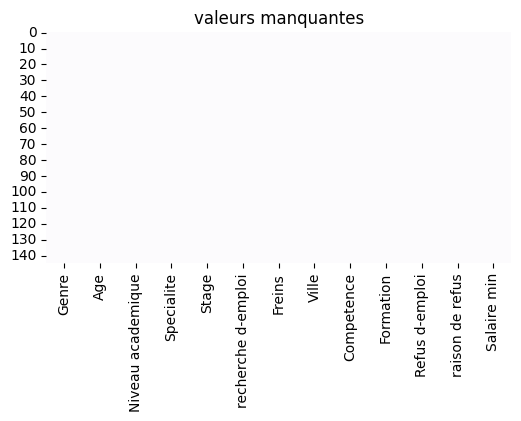

In [28]:
#valeur manquantes

plt.figure(figsize=(6, 3), facecolor='white')
sns.heatmap(df.isnull(),cbar=False,cmap='Purples')
plt.title('valeurs manquantes')
plt.show()

In [29]:
# Statistiques numériques

df.describe()

,Genre,Niveau academique,Salaire min
count,145.000000,145.000000,145.000000
mean,0.551724,4.310345,9738.613793
std,0.499041,1.672977,8554.647942
min,0.000000,0.000000,2500.000000
25%,0.000000,3.000000,6000.000000
50%,1.000000,5.000000,8000.000000
75%,1.000000,5.000000,10000.000000
max,1.000000,9.000000,80000.000000


In [30]:
# Statistiques catégoriques

df.describe(include='object')

,Age,Specialite,Stage,recherche d-emploi,Freins,Ville,Competence,Formation,Refus d-emploi,raison de refus
count,145,145,145,145,145,145,145,145,145,145
unique,6,6,2,3,5,10,5,3,2,7
top,[20;25[,Mathématique,Oui,Non,Manque d’expérience,rabat,Expériences ou stages,Moyennement,Non,Pas de refus
freq,78,43,100,60,63,59,58,79,89,89


/tmp/ipykernel_5066/3739798286.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=column_name, data=self.data, palette='BuGn')


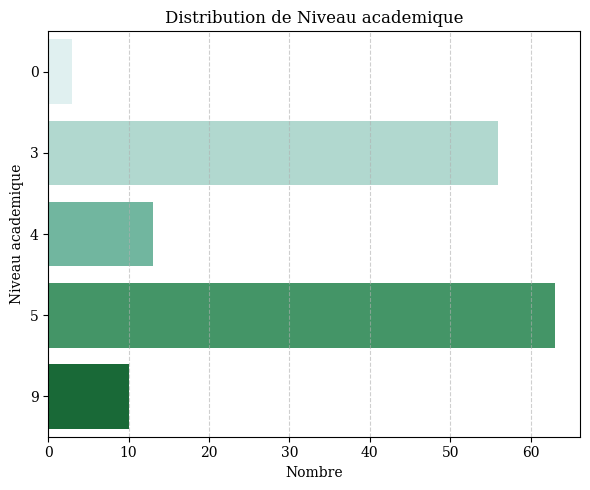

/tmp/ipykernel_5066/3739798286.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=column_name, data=self.data, palette='BuGn')


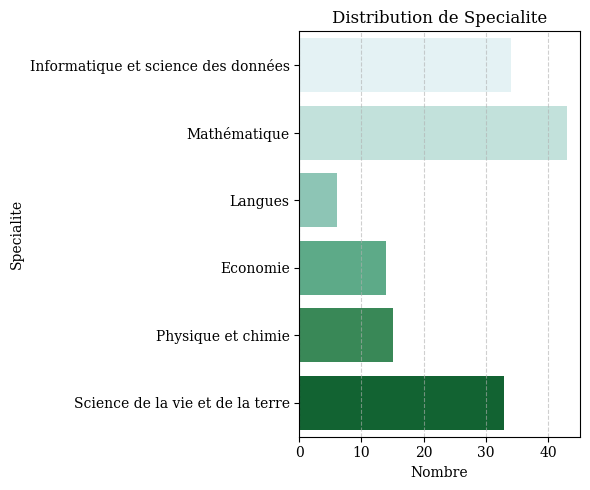

/tmp/ipykernel_5066/3739798286.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=column_name, data=self.data, palette='BuGn')


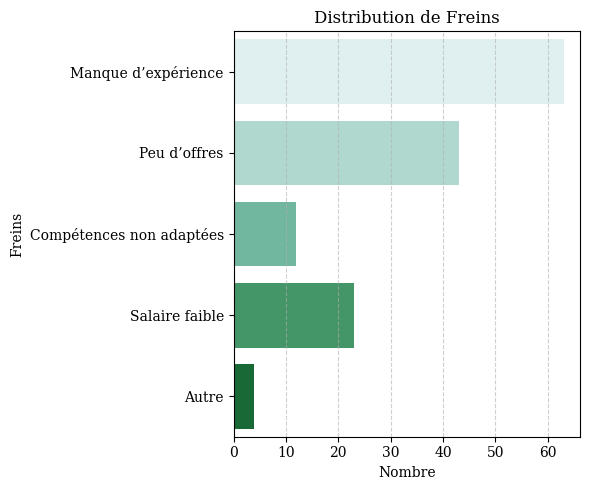

/tmp/ipykernel_5066/3739798286.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=column_name, data=self.data, palette='BuGn')


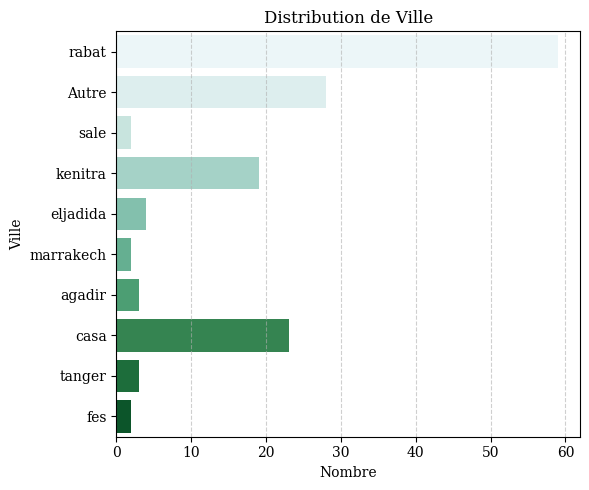

/tmp/ipykernel_5066/3739798286.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=column_name, data=self.data, palette='BuGn')


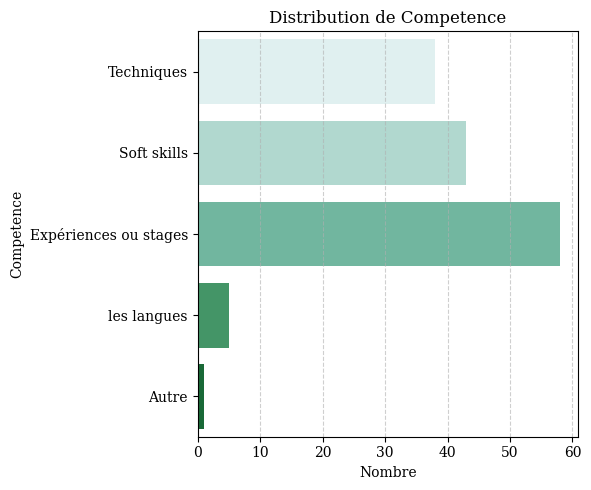

/tmp/ipykernel_5066/3739798286.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=column_name, data=self.data, palette='BuGn')


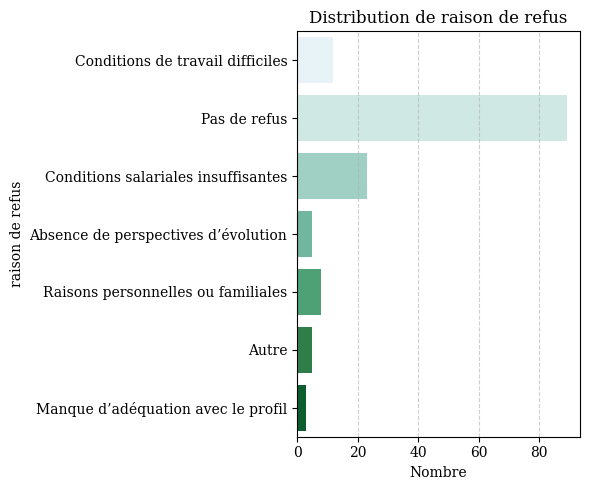

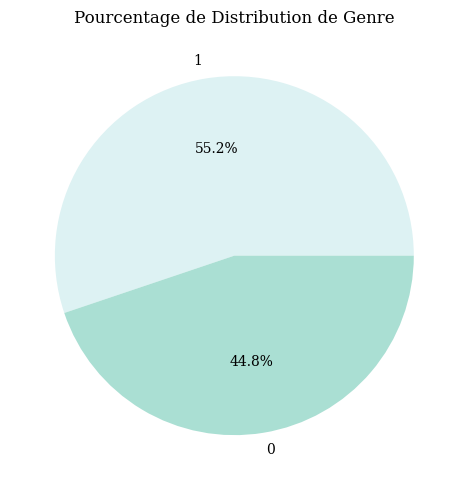

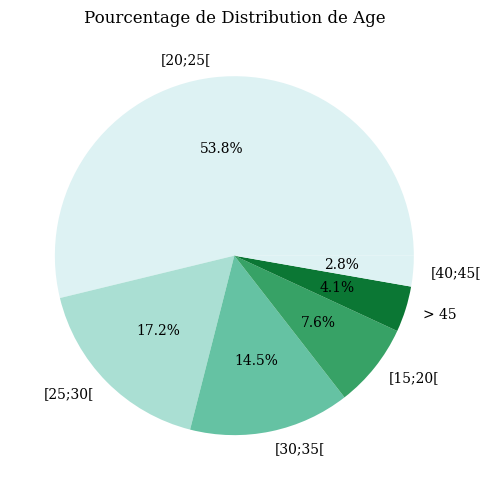

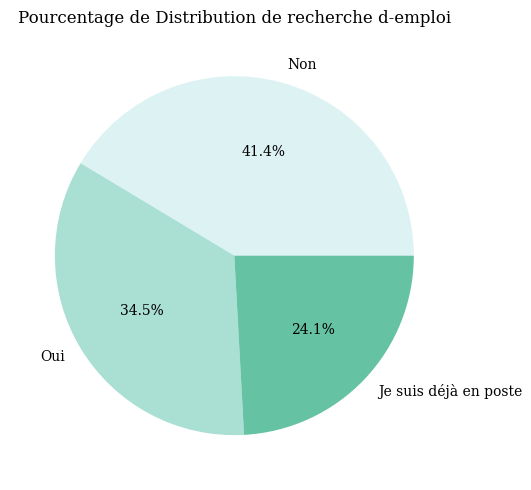

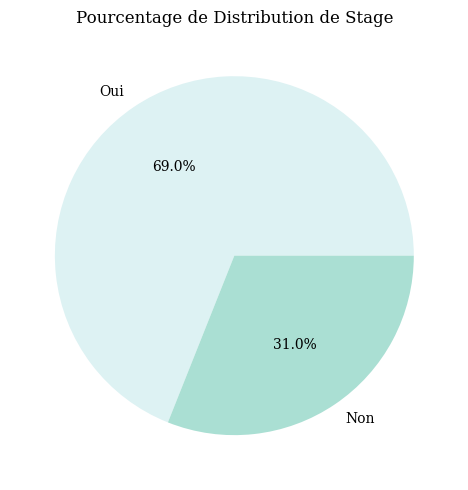

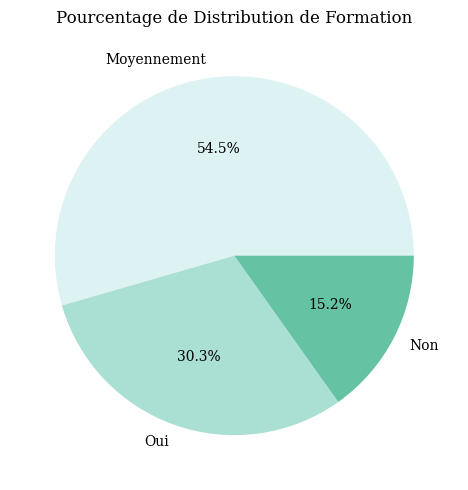

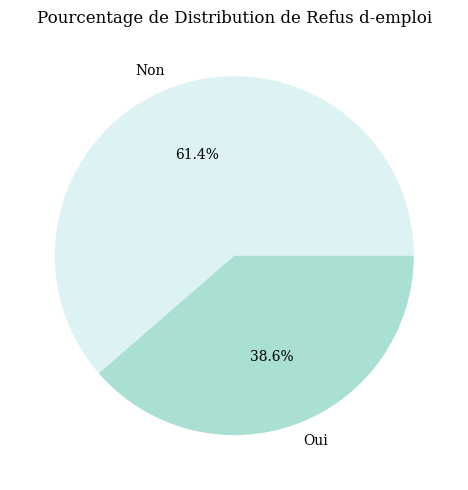

In [31]:
#Analyse univariée

from matplotlib import rcParams
from matplotlib.ticker import FuncFormatter

class Show:
    def __init__(self, data):
        self.data = data
       
    def distribution(self, column_name):
        rcParams['font.family'] = 'serif'
        plt.figure(figsize=(6, 5))
        sns.countplot(y=column_name, data=self.data, palette='BuGn')
        plt.title(f'Distribution de {column_name}')
        plt.grid(axis='x', linestyle='--', alpha=0.6)

        plt.xlabel('Nombre')
        plt.ylabel(column_name) 
        plt.tight_layout()
        plt.show()

    def pourcentage(self, column_name):
        rcParams['font.family'] = 'serif'
        plt.figure(figsize=(6, 5))
        self.data[column_name].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette("BuGn", n_colors=5))
        plt.title(f'Pourcentage de Distribution de {column_name}')
        plt.ylabel('')
        plt.tight_layout()
        plt.show()



liste1=['Niveau academique', 'Specialite','Freins', 'Ville', 'Competence','raison de refus']
liste2=['Genre', 'Age', 'recherche d-emploi','Stage','Formation','Refus d-emploi']

visualizer = Show(df)
for colomn in liste1:
    visualizer.distribution(colomn)
for colomn in liste2:    
    visualizer.pourcentage(colomn)

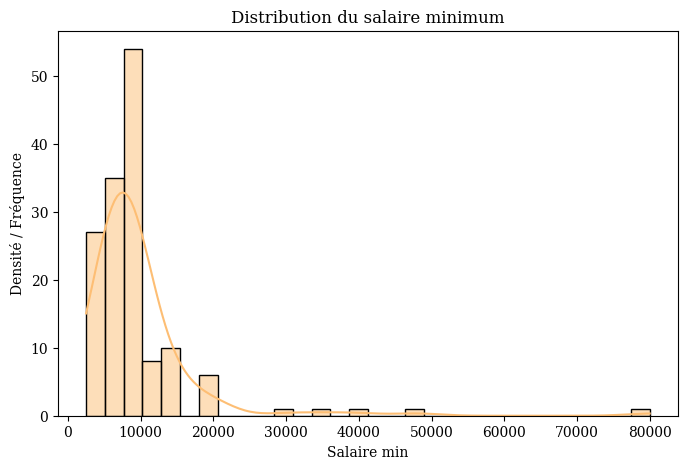

In [32]:
plt.figure(figsize=(8,5))
sns.histplot(df['Salaire min'], kde=True, bins=30, color='#FDBE74')
plt.title("Distribution du salaire minimum")
plt.xlabel("Salaire min")
plt.ylabel("Densité / Fréquence")
plt.show()

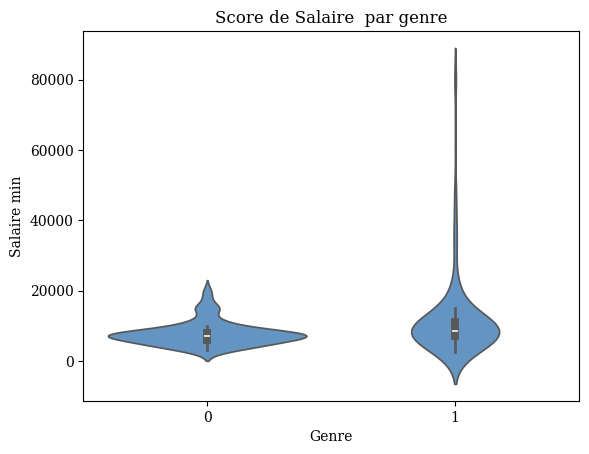

In [33]:
#Analyse bivariee
sns.violinplot(x='Genre', y='Salaire min',color='#5495d1', data=df)
plt.title('Score de Salaire  par genre')
plt.show()

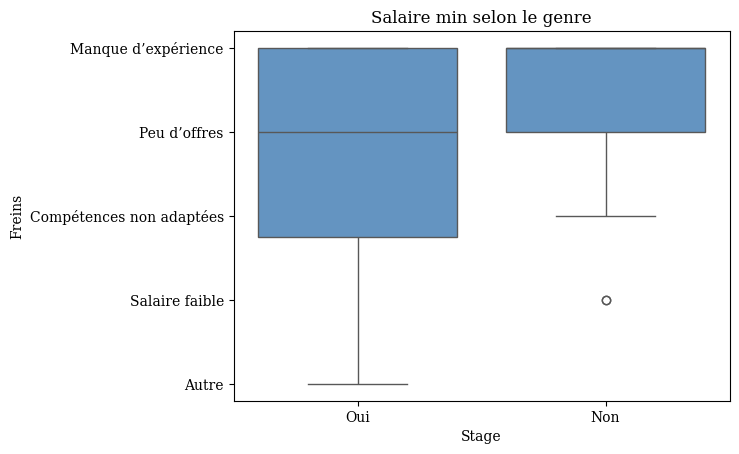

In [34]:
sns.boxplot(x='Stage', y='Freins',color='#5495d1', data=df)
plt.title('Salaire min selon le genre')
plt.show()

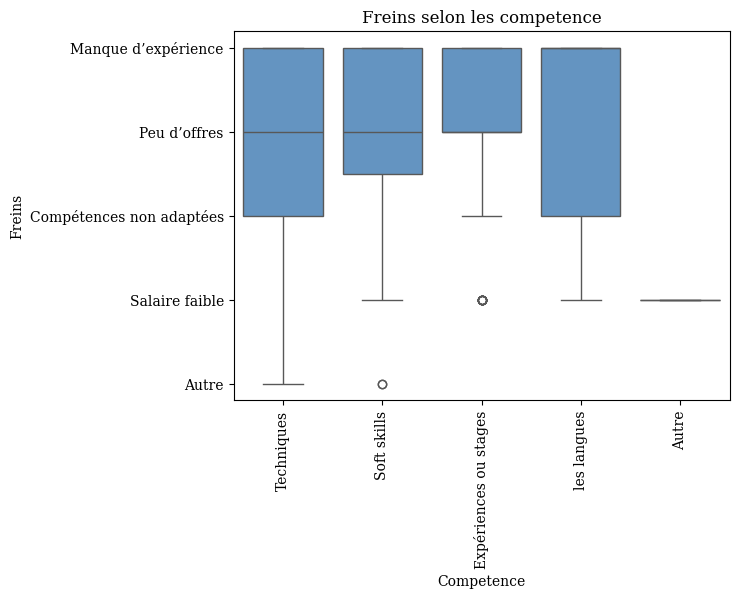

In [35]:
sns.boxplot(x='Competence', y='Freins',color='#5495d1', data=df)
plt.title('Freins selon les competence')
plt.xticks(rotation=90)
plt.show()

In [36]:
#teste khi2
from scipy.stats import chi2_contingency


In [37]:
#Freins

for col in df.columns:
    if col == 'Freins':
        continue 
    table = pd.crosstab(df[col], df['Freins'])
    try:
        chi2, p, dof, expected = chi2_contingency(table)
        print(f"La p-value entre '{col}' et 'Freins' est : {p:.4f}")
    except ValueError as e:
        print(f"Impossible de calculer le chi2 pour la colonne '{col}': {e}")

La p-value entre 'Genre' et 'Freins' est : 0.2049
La p-value entre 'Age' et 'Freins' est : 0.7337
La p-value entre 'Niveau academique' et 'Freins' est : 0.6903
La p-value entre 'Specialite' et 'Freins' est : 0.7663
La p-value entre 'Stage' et 'Freins' est : 0.0208
La p-value entre 'recherche d-emploi' et 'Freins' est : 0.0371
La p-value entre 'Ville' et 'Freins' est : 0.9693
La p-value entre 'Competence' et 'Freins' est : 0.7120
La p-value entre 'Formation' et 'Freins' est : 0.0321
La p-value entre 'Refus d-emploi' et 'Freins' est : 0.3338
La p-value entre 'raison de refus' et 'Freins' est : 0.3041
La p-value entre 'Salaire min' et 'Freins' est : 0.0784


In [39]:
#Variante asymétrique de Cramér’s V.

from dython.nominal import theils_u

/usr/local/python/3.12.1/lib/python3.12/site-packages/dython/__init__.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution


In [40]:
matrix = pd.DataFrame(index=df.columns, columns=['Freins'])

for col in df.columns:
        u = theils_u(df[col], df['Freins'])
        matrix.loc[col, 'Freins'] = np.round(u, 3)

print(matrix)

                   Freins
Genre               0.031
Age                  0.04
Niveau academique   0.038
Specialite          0.034
Stage               0.077
recherche d-emploi  0.057
Freins                1.0
Ville               0.045
Competence          0.038
Formation           0.064
Refus d-emploi      0.031
raison de refus     0.086
Salaire min         0.124


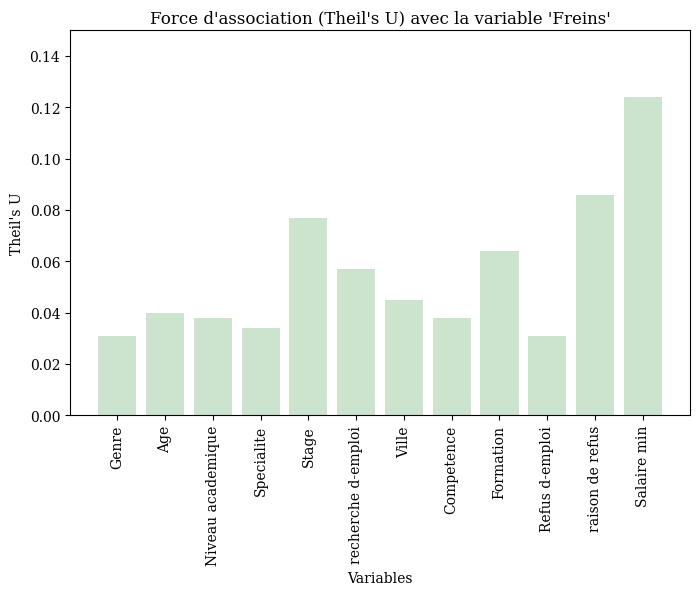

In [41]:

theils_u_values = {
    'Genre': 0.031,
    'Age': 0.040,
    'Niveau academique': 0.038,
    'Specialite': 0.034,
    'Stage': 0.077,
    'recherche d-emploi': 0.057,
    'Ville': 0.045,
    'Competence': 0.038,
    'Formation': 0.064,
    'Refus d-emploi': 0.031,
    'raison de refus': 0.086,
    'Salaire min': 0.124,
}

variables = list(theils_u_values.keys())
values = list(theils_u_values.values())

plt.figure(figsize=(8,5))
bars = plt.bar(variables, values, color='#cce4cd')
plt.ylim(0, 0.15)
plt.title("Force d'association (Theil's U) avec la variable 'Freins'")
plt.ylabel("Theil's U")
plt.xlabel("Variables")
plt.xticks(rotation=90)

plt.show()


In [43]:
#analyse multivariee 

from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix


In [44]:
df = df[df['Freins'] != 'Autre']
X = df[['Salaire min', 'Stage', 'Formation', 'Refus d-emploi']]
y = df['Freins']

categorical_features = ['Stage', 'Formation', 'Refus d-emploi']
numerical_features = ['Salaire min']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_features),
        ('num', 'passthrough', numerical_features)
    ])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Appliquer SMOTE sur les données d'entraînement seulement
smote = SMOTE(random_state=42)
X_train_enc = preprocessor.fit_transform(X_train)
X_train_res, y_train_res = smote.fit_resample(X_train_enc, y_train)

# Entraîner le modèle sur les données sur-échantillonnées
model.named_steps['classifier'].fit(X_train_res, y_train_res)

# Préparer test encodé et prédire
X_test_enc = preprocessor.transform(X_test)
y_pred = model.named_steps['classifier'].predict(X_test_enc)

# Évaluer
print("Rapport de classification :\n", classification_report(y_test, y_pred))

Rapport de classification :
                           precision    recall  f1-score   support

Compétences non adaptées       0.20      1.00      0.33         1
     Manque d’expérience       0.62      0.42      0.50        12
            Peu d’offres       0.46      0.50      0.48        12
          Salaire faible       0.00      0.00      0.00         4

                accuracy                           0.41        29
               macro avg       0.32      0.48      0.33        29
            weighted avg       0.46      0.41      0.42        29



In [45]:
# Fusionner "Peu d’offres" et "Salaire faible" en "Offres limités"
df['Freins_fusion'] = df['Freins'].replace({
    'Peu d’offres': 'Offres limités',
    'Salaire faible': 'Offres limités'
})

print(df['Freins_fusion'].value_counts())


Freins_fusion
Offres limités              66
Manque d’expérience         63
Compétences non adaptées    12
Name: count, dtype: int64


/tmp/ipykernel_5066/1938707147.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Freins_fusion'] = df['Freins'].replace({


In [46]:
# 2. Variables explicatives (adapter selon ton dataset)
X = df[['Salaire min', 'Stage', 'Formation', 'Refus d-emploi']]
y = df['Freins_fusion']

# 3. Définir colonnes catégorielles et numériques
categorical_features = ['Stage', 'Formation', 'Refus d-emploi']
numerical_features = ['Salaire min']

# 4. Préprocessing
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(drop='first'), categorical_features),
    ('num', 'passthrough', numerical_features)
])

# 5. Séparer train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Encoder train pour SMOTE
X_train_enc = preprocessor.fit_transform(X_train)

# 7. Appliquer SMOTE sur les données d'entraînement uniquement
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_enc, y_train)

# 8. Entraîner le modèle RandomForest
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train_res, y_train_res)

# 9. Préparer et prédire sur test
X_test_enc = preprocessor.transform(X_test)
y_pred = clf.predict(X_test_enc)

# 10. Évaluer
print("Rapport de classification :\n", classification_report(y_test, y_pred))
print("Matrice de confusion :\n", confusion_matrix(y_test, y_pred))

Rapport de classification :
                           precision    recall  f1-score   support

Compétences non adaptées       0.20      1.00      0.33         1
     Manque d’expérience       0.71      0.42      0.53        12
          Offres limités       0.71      0.75      0.73        16

                accuracy                           0.62        29
               macro avg       0.54      0.72      0.53        29
            weighted avg       0.69      0.62      0.63        29

Matrice de confusion :
 [[ 1  0  0]
 [ 2  5  5]
 [ 2  2 12]]


In [47]:

new_data = pd.DataFrame({
    'Salaire min': [10000],          
    'Stage': ['Non'],                
    'Formation': ['Oui'],          
    'Refus d-emploi': ['Oui']        
})

new_data_enc = preprocessor.transform(new_data)

predicted_class = clf.predict(new_data_enc)

print("Freins prédits pour ces valeurs :", predicted_class[0])


Freins prédits pour ces valeurs : Offres limités
